# 3 — TotalSegmentator Tabanlı Z-Ekseni Organ Sınır Tespiti

YOLO'nun 2D görüntüde `(x1, y1, x2, y2)` bbox tespiti yapması gibi,  
bu notebook bir CT hacminde her organ için `(z_start, z_end)` kesit aralığını tespit eder.

**Akış:**
1. Bilgi.xlsx → Boundary Slice GT analizi  
2. TotalSegmentator kurulum kontrolü  
3. Tek vaka üzerinde z-profil görselleştirme  
4. Toplu tahmin (validation seti)  
5. GT karşılaştırması ve MAE hesabı  
6. Eşik kalibrasyonu (Faz 2)

In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import os
# ── Yollar ──────────────────────────────────────────────────────────────────
ROOT      =  Path(os.environ.get("TR_ABDOMEN_PROJE", r"D:/makale-pdf/Proje/abdomen"))
DATA_ROOT = ROOT
SPLIT_DIR = ROOT / 'outputs' / 'splits'
SEG_DIR   = ROOT / 'outputs' / 'seg_data'


DATASET_ROOT = Path(os.environ.get("TR_ABDOMEN_BASE", r"D:/makale-pdf/Proje/abdomenDataSet"))
EGITIM_DIR = Path(os.environ.get("ABDOMEN_TRAIN_DIR", DATASET_ROOT / "Egitim Verisi"))
YARISMA_DIR = Path(os.environ.get("ABDOMEN_TEST_DIR", DATASET_ROOT / "Test Verisi"))
BILGI     = DATASET_ROOT / 'Bilgi.xlsx'



TS_CACHE  = SEG_DIR / 'ts_cache'
NII_CACHE = SEG_DIR / 'nii_cache'
TS_CACHE.mkdir(parents=True, exist_ok=True)
NII_CACHE.mkdir(parents=True, exist_ok=True)

sys.path.insert(0, str(ROOT.parent))
print('ROOT:', ROOT)
print('Bilgi.xlsx:', BILGI.exists())

ROOT: /Users/ramazanpolat/Desktop/datasets/abdomen
Bilgi.xlsx: True


## 1 — Bilgi.xlsx: Boundary Slice GT Analizi

In [4]:
from src.boundary_z_detect import (
    build_gt_from_bilgi, build_image_id_to_zidx, OUR_ORGANS
)

MANIFEST_CSV = SPLIT_DIR / 'manifest.csv'

# # Image Id → z-index eşlemesini göster (ilk vaka örneği)
# id_to_z = build_image_id_to_zidx(MANIFEST_CSV)
# sample_case = list(id_to_z.keys())[0]
# sample_map  = id_to_z[sample_case]
# print(f'Örnek eşleme — vaka {sample_case}:')
# print(f'  Toplam kesit: {len(sample_map)}')
# for img_id, z in sorted(sample_map.items())[:8]:
#     print(f'  Image Id {img_id}  →  z-index {z}')
# print('  ...')
# print()



In [5]:

# GT: Image Id → z-index dönüşümü manifest üzerinden yapılır
gt_df = build_gt_from_bilgi(BILGI, MANIFEST_CSV)

print('Örnek GT satırları (z-index cinsinden):')
print(gt_df.head(10).to_string(index=False))

  [build_gt] 9 organ-vaka atlandı (tek boundary veya manifest'te yok)
Örnek GT satırları (z-index cinsinden):
   case           organ  img_id_start  img_id_end  z_start  z_end
C_20001 Abdominal Aorta        100017      100047       66     96
C_20001           Colon        100014      100075       38     99
C_20001    Gall bladder        100019      100029       84     94
C_20001  Kidney-Bladder        100021      100091       22     92
C_20001        Pancreas        100018      100039       74     95
C_20001        appendix        100058      100079       34     55
C_20002 Abdominal Aorta        100156      100210      121    175
C_20002           Colon        100135      100297       34    196
C_20002    Gall bladder        100161      100198      133    170
C_20002  Kidney-Bladder        100157      100309       22    174


In [6]:
print(f'Toplam Boundary Slice annotasyonu: {len(gt_df)} satır')
print(f'Benzersiz vaka: {gt_df["case"].nunique()}')
print()
print('Organ bazlı annotasyon sayısı:')
print(gt_df.groupby('organ').size().sort_values(ascending=False).to_string())
print()

Toplam Boundary Slice annotasyonu: 3933 satır
Benzersiz vaka: 1090

Organ bazlı annotasyon sayısı:
organ
Abdominal Aorta                         714
Kidney-Bladder                          660
Pancreas                                604
Gall bladder                            573
Colon                                   562
appendix                                523
Compatible with acute cholecystitis     113
Compatible with acute pancreatitis       99
Gallbladder stone                        45
Kidney stone                             17
ureteral stone                           15
Abdominal aortic aneurysm                 3
Compatible with acute appendicitis        3
Calcified diverticulum                    1
Compatible with acute diverticulitis      1



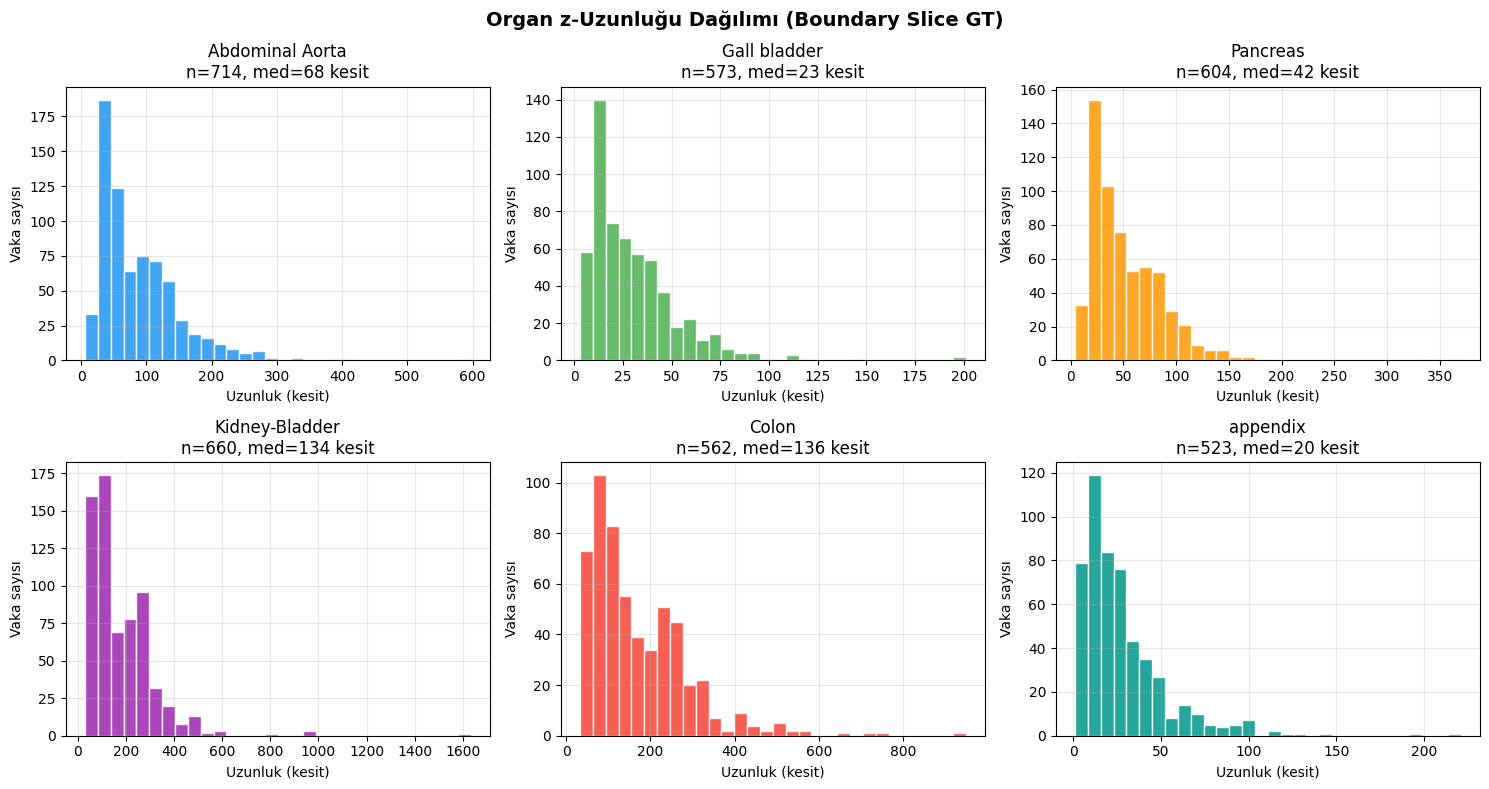

Kaydedildi: boundary_gt_distribution.png


In [7]:
# Organ uzunluklarının dağılımı (kesit cinsinden)
gt_df['length'] = gt_df['z_end'] - gt_df['z_start']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
colors = ['#2196F3','#4CAF50','#FF9800','#9C27B0','#F44336','#009688']

for i, organ in enumerate(OUR_ORGANS):
    sub = gt_df[gt_df['organ'] == organ]['length']
    if len(sub) == 0:
        axes[i].set_title(f'{organ}\n(annotasyon yok)')
        continue
    axes[i].hist(sub, bins=30, color=colors[i], edgecolor='white', alpha=0.85)
    axes[i].set_title(f'{organ}\nn={len(sub)}, med={sub.median():.0f} kesit')
    axes[i].set_xlabel('Uzunluk (kesit)')
    axes[i].set_ylabel('Vaka sayısı')
    axes[i].grid(True, alpha=0.3)

plt.suptitle('Organ z-Uzunluğu Dağılımı (Boundary Slice GT)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('boundary_gt_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Kaydedildi: boundary_gt_distribution.png')

In [8]:
# Özet istatistik tablosu
summary = gt_df.groupby('organ')['length'].agg(['count','mean','median','min','max'])
summary.columns = ['n_vaka', 'ort_uzunluk', 'med_uzunluk', 'min', 'max']
summary = summary.round(1)
print('Boundary Slice GT Özet İstatistikleri (kesit cinsinden):')
print(summary.to_string())

Boundary Slice GT Özet İstatistikleri (kesit cinsinden):
                                      n_vaka  ort_uzunluk  med_uzunluk  min   max
organ                                                                            
Abdominal Aorta                          714         87.3         68.0    6   597
Abdominal aortic aneurysm                  3        129.0        113.0   57   217
Calcified diverticulum                     1         14.0         14.0   14    14
Colon                                    562        170.2        136.5   33   948
Compatible with acute appendicitis         3         19.3          9.0    6    43
Compatible with acute cholecystitis      113         47.9         33.0    6   596
Compatible with acute diverticulitis       1         18.0         18.0   18    18
Compatible with acute pancreatitis        99         50.1         40.0   10   164
Gall bladder                             573         30.0         23.0    3   201
Gallbladder stone                        

## 2 — TotalSegmentator Kurulum Kontrolü

In [ ]:
# import subprocess

# # TotalSegmentator kurulu mu?
# result = subprocess.run(['TotalSegmentator', '--help'], capture_output=True, text=True)
# if result.returncode == 0:
#     print('✅ TotalSegmentator kurulu ve çalışıyor.')
#     # Versiyon bilgisi
#     ver = subprocess.run(['TotalSegmentator', '--version'], capture_output=True, text=True)
#     print('Versiyon:', ver.stdout.strip() or ver.stderr.strip())
# else:
#     print('❌ TotalSegmentator bulunamadı.')
#     print('Kurulum: pip install TotalSegmentator')
#     print()
#     print('Kurulum sonrası model indirme (ilk çalıştırmada otomatik yapılır).')
#     print('Tahmini boyut: ~2GB (fast model)')

In [11]:
# SimpleITK kontrolü
try:
    import SimpleITK as sitk
    print('✅ SimpleITK:', sitk.Version_VersionString())
except ImportError:
    print('❌ SimpleITK kurulu değil → pip install SimpleITK')

# boundary_z_detect modülü
try:
    from src.boundary_z_detect import (
        predict_boundaries_zero_shot,
        _z_profile, _detect_interval,
        BoundaryCalibrator, evaluate,
        OUR_ORGANS, TS_ORGAN_MAP
    )
    print('✅ boundary_z_detect modülü yüklendi.')
    print(f'   Takip edilen organlar ({len(OUR_ORGANS)}):', OUR_ORGANS)
except Exception as e:
    print(f'❌ Modül yüklenemedi: {e}')

✅ SimpleITK: 2.5.3
✅ boundary_z_detect modülü yüklendi.
   Takip edilen organlar (6): ['Abdominal Aorta', 'Gall bladder', 'Pancreas', 'Kidney-Bladder', 'Colon', 'appendix']


## 3 — Tek Vaka: z-Profil Görselleştirme

TotalSegmentator çıktısı zaten varsa `ts_cache` dizininden okunur.  
Yoksa otomatik çalıştırılır (~2-5 dakika/vaka, fast mod).

In [9]:
# Test edilecek vakayı seç — val setindeki ilk vakaları listele
val_cases = pd.read_csv(SPLIT_DIR / 'fold0_val.csv')['Case Number'].tolist()
print(f'Validation seti: {len(val_cases)} vaka')
print('İlk 10:', val_cases[:10])

# GT annotasyonu olan vakalarla kesişim
gt_cases = set(gt_df['case'].tolist())
annotated_val = [c for c in val_cases if c in gt_cases]
print(f'GT boundary annotasyonlu val vakası: {len(annotated_val)}')

Validation seti: 145 vaka
İlk 10: ['C_20294', 'C_20112', 'C_20012', 'T_20077', 'T_20119', 'T_20480', 'T_20127', 'T_20317', 'T_20229', 'T_20544']
GT boundary annotasyonlu val vakası: 144


In [10]:
# İlk annotasyonlu vakayı seç ve TotalSegmentator çalıştır
# (önceden hesaplandıysa ts_cache'den okur, tekrar çalışmaz)

TEST_CASE_ID = annotated_val[0] if annotated_val else val_cases[0]
print(f'Test vakası: {TEST_CASE_ID}')

# Vaka dizinini bul (train veya test'te olabilir)
case_dir = None
for src in (EGITIM_DIR, YARISMA_DIR):
    candidate = src / str(TEST_CASE_ID)
    if candidate.exists():
        case_dir = candidate
        break

if case_dir is None:
    print(f'HATA: {TEST_CASE_ID} dizini bulunamadı.')
else:
    print(f'Dizin: {case_dir}')
    dcm_files = list(case_dir.glob('*.dcm'))
    print(f'DICOM kesit sayısı: {len(dcm_files)}')

Test vakası: C_20294
HATA: C_20294 dizini bulunamadı.


In [ ]:
# TotalSegmentator çalıştır ve sınırları tespit et
# (Bu hücre TS kurulu değilse hata verir — kurulum sonrası çalıştırın)

if case_dir is not None:
    print(f'TotalSegmentator çalıştırılıyor (fast mod)...')
    print('İlk çalıştırmada model indiriliyor (~2GB), sonraki çalıştırmalar hızlı.')
    
    preds = predict_boundaries_zero_shot(
        case_dir,
        ts_cache_dir=TS_CACHE,
        nii_cache_dir=NII_CACHE,
        threshold=0.005,
        min_run=2,
    )
    
    print(f'\n--- Vaka {TEST_CASE_ID} Sınır Tespiti ---')
    #print(f'{'Organ':<25} {'z_start':>8} {'z_end':>8} {'uzunluk':>8}')
    print('-' * 55)
    for organ, iv in preds.items():
        if iv:
            print(f'{organ:<25} {iv[0]:>8} {iv[1]:>8} {iv[1]-iv[0]+1:>8}')
        else:
            print(f'{organ:<25} {"—":>8} {"—":>8} {"—":>8}')
    
    # GT ile karşılaştır
    gt_case = gt_df[gt_df['case'] == TEST_CASE_ID]
    if len(gt_case) > 0:
        print(f'\n--- GT Boundary Slice (Bilgi.xlsx) ---')
        for _, row in gt_case.iterrows():
            print(f'{row["organ"]:<25} {int(row["z_start"]):>8} {int(row["z_end"]):>8} {int(row["z_end"]-row["z_start"]+1):>8}')

In [ ]:
# z-Profil görselleştirme
# (TS çıktısı ts_cache'de olmalı)

ts_out = TS_CACHE / str(TEST_CASE_ID)

if ts_out.exists() and any(ts_out.glob('*.nii.gz')):
    fig, axes = plt.subplots(2, 3, figsize=(16, 9))
    axes = axes.flatten()
    colors = ['#2196F3','#4CAF50','#FF9800','#9C27B0','#F44336','#009688']
    
    # Tüm sliceların sayısını referans için oku
    import SimpleITK as sitk
    nii_path = NII_CACHE / f'{TEST_CASE_ID}.nii.gz'
    if nii_path.exists():
        ref = sitk.ReadImage(str(nii_path))
        n_slices = sitk.GetArrayFromImage(ref).shape[0]
    else:
        n_slices = None
    
    for i, organ in enumerate(OUR_ORGANS):
        ax = axes[i]
        
        # Organ maskelerini birleştir
        combined_profile = None
        for ts_name, our_name in TS_ORGAN_MAP.items():
            if our_name != organ:
                continue
            mask_path = ts_out / f'{ts_name}.nii.gz'
            if not mask_path.exists():
                continue
            prof = _z_profile(mask_path)
            combined_profile = prof if combined_profile is None else np.maximum(combined_profile, prof)
        
        if combined_profile is None:
            ax.set_title(f'{organ}\n(TS çıktısı yok)', fontsize=9)
            ax.axis('off')
            continue
        
        z_vals = np.arange(len(combined_profile))
        ax.fill_between(z_vals, combined_profile, alpha=0.4, color=colors[i])
        ax.plot(z_vals, combined_profile, color=colors[i], lw=1.5)
        ax.axhline(0.005, color='gray', ls='--', lw=1, label='eşik=0.005')
        
        # Tespit edilen aralık
        interval = _detect_interval(combined_profile, threshold=0.005, min_run=2)
        if interval:
            ax.axvspan(interval[0], interval[1], alpha=0.15, color='red', label=f'Tespit: [{interval[0]},{interval[1]}]')
        
        # GT aralığı
        gt_row = gt_df[(gt_df['case'] == TEST_CASE_ID) & (gt_df['organ'] == organ)]
        if len(gt_row) > 0:
            z0, z1 = int(gt_row.iloc[0]['z_start']), int(gt_row.iloc[0]['z_end'])
            ax.axvspan(z0, z1, alpha=0.15, color='green', label=f'GT: [{z0},{z1}]')
        
        ax.set_title(f'{organ}', fontsize=9, fontweight='bold')
        ax.set_xlabel('Kesit (z)', fontsize=8)
        ax.set_ylabel('Organ kesri', fontsize=8)
        ax.legend(fontsize=7)
        ax.grid(True, alpha=0.3)
    
    red_p = mpatches.Patch(color='red', alpha=0.3, label='Tespit edilen aralık')
    green_p = mpatches.Patch(color='green', alpha=0.3, label='GT (Bilgi.xlsx)')
    fig.legend(handles=[red_p, green_p], loc='upper center', ncol=2, fontsize=10, bbox_to_anchor=(0.5, 1.01))
    
    plt.suptitle(f'Vaka {TEST_CASE_ID} — z-Ekseni Organ z-Profilleri', fontsize=13, fontweight='bold', y=1.03)
    plt.tight_layout()
    plt.savefig(f'boundary_profile_case{TEST_CASE_ID}.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Kaydedildi: boundary_profile_case{TEST_CASE_ID}.png')
else:
    print('TS çıktısı henüz yok. Önce TotalSegmentator çalıştırın.')

## 4 — Toplu Tahmin: Validation Seti

In [ ]:
# Validation setindeki tüm vakalar üzerinde çalıştır
# Not: Her vaka için TS ~2-5 dakika. İlk çalıştırmada ts_cache boş olduğundan uzun sürer.
# Sonraki çalıştırmalarda ts_cache'den okur, çok hızlıdır.

from src.boundary_z_detect import run_dataset
from tqdm import tqdm

val_case_dirs = []
for case_id in val_cases:
    for src in (EGITIM_DIR, YARISMA_DIR):
        candidate = src / str(case_id)
        if candidate.exists():
            val_case_dirs.append(candidate)
            break

print(f'Val dizini bulunan vaka sayısı: {len(val_case_dirs)} / {len(val_cases)}')

# Sadece GT annotasyonu olan vakalar (değerlendirme için)
val_gt_cases = [d for d in val_case_dirs if int(d.name) in gt_cases]
print(f'GT annotasyonlu: {len(val_gt_cases)} vaka')

In [ ]:
# Toplu tahmin — ts_cache'de olmayanlar için TS çalıştırılır
PRED_CSV = Path('boundary_preds_val.csv')

if PRED_CSV.exists():
    print(f'Mevcut tahmin dosyası okunuyor: {PRED_CSV}')
    pred_df = pd.read_csv(PRED_CSV)
else:
    pred_df = run_dataset(
        val_gt_cases,          # GT annotasyonlu vakalar
        ts_cache_dir=TS_CACHE,
        nii_cache_dir=NII_CACHE,
    )
    pred_df.to_csv(PRED_CSV, index=False)
    print(f'Kaydedildi: {PRED_CSV}')

print(f'Tahmin sayısı: {len(pred_df)} (vaka × organ)')
print()
print(pred_df.groupby('organ').size().sort_values(ascending=False).to_string())

## 5 — GT Karşılaştırması: MAE Değerlendirmesi

In [ ]:
# Val seti GT'si (z-index cinsinden)
gt_val = build_gt_from_bilgi(BILGI, MANIFEST_CSV)
gt_val = gt_val[gt_val['case'].isin([int(d.name) for d in val_gt_cases])]

# Evaluate
result_df = evaluate(pred_df.to_dict('records'), gt_val)
print('=== Organ Sınır Tespiti — MAE (z-index = kesit cinsinden) ===')
print(result_df.to_string(index=False))

overall_mae = result_df[['mae_z_start','mae_z_end']].mean().mean()
print(f'\nGenel ortalama MAE: {overall_mae:.1f} kesit')
print()
print('Not: Kesit kalınlığı genellikle 2-5mm.')
print(f'  5 kesit hata  → ~10-25mm  (klinik olarak kabul edilebilir)')
print(f'  10 kesit hata → ~20-50mm  (iyileştirme gerekli)')

In [ ]:
# Organ bazlı MAE bar grafik
if len(result_df) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    colors_bar = ['#2196F3','#4CAF50','#FF9800','#9C27B0','#F44336','#009688']

    # z_start MAE
    axes[0].barh(result_df['organ'], result_df['mae_z_start'],
                 color=colors_bar[:len(result_df)], edgecolor='white')
    axes[0].set_title('z_start MAE (kesit)', fontweight='bold')
    axes[0].set_xlabel('Ortalama Mutlak Hata (kesit)')
    axes[0].grid(True, alpha=0.3, axis='x')
    for i, v in enumerate(result_df['mae_z_start']):
        axes[0].text(v + 0.3, i, f'{v:.1f}', va='center', fontsize=9)

    # z_end MAE
    axes[1].barh(result_df['organ'], result_df['mae_z_end'],
                 color=colors_bar[:len(result_df)], edgecolor='white')
    axes[1].set_title('z_end MAE (kesit)', fontweight='bold')
    axes[1].set_xlabel('Ortalama Mutlak Hata (kesit)')
    axes[1].grid(True, alpha=0.3, axis='x')
    for i, v in enumerate(result_df['mae_z_end']):
        axes[1].text(v + 0.3, i, f'{v:.1f}', va='center', fontsize=9)

    plt.suptitle('TotalSegmentator Z-Sınır Tespiti — Organ MAE (Faz 1: Sıfır-shot)', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig('boundary_mae_results.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Kaydedildi: boundary_mae_results.png')

In [ ]:
# Scatter plot: tahmin vs gerçek z_start (tüm organlar birlikte)
merged = pd.merge(
    pred_df, gt_val,
    on=['case','organ'], suffixes=('_pred','_gt')
)

if len(merged) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    organ_list = merged['organ'].unique()
    color_map = {o: c for o, c in zip(organ_list, ['#2196F3','#4CAF50','#FF9800','#9C27B0','#F44336','#009688'])}

    for organ in organ_list:
        sub = merged[merged['organ'] == organ]
        c = color_map[organ]
        axes[0].scatter(sub['z_start_gt'], sub['z_start_pred'], label=organ, color=c, alpha=0.6, s=30)
        axes[1].scatter(sub['z_end_gt'],   sub['z_end_pred'],   label=organ, color=c, alpha=0.6, s=30)

    max_val = merged[['z_start_gt','z_start_pred','z_end_gt','z_end_pred']].max().max()
    for ax, title in zip(axes, ['z_start', 'z_end']):
        ax.plot([0, max_val], [0, max_val], 'k--', lw=1, alpha=0.5, label='Mükemmel')
        ax.set_xlabel(f'{title} GT (kesit)')
        ax.set_ylabel(f'{title} Tahmin (kesit)')
        ax.set_title(f'{title} — GT vs Tahmin')
        ax.legend(fontsize=7, loc='upper left')
        ax.grid(True, alpha=0.3)

    plt.suptitle('Sıfır-shot Tahmin vs GT', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig('boundary_scatter.png', dpi=150, bbox_inches='tight')
    plt.show()

## 6 — Faz 2: Eşik Kalibrasyonu (BoundaryCalibrator)

In [ ]:
# Kalibrasyon için train setindeki z-profillerini oku
# (ts_cache'de TotalSegmentator çıktıları olmalı)

train_cases_ids = pd.read_csv(SPLIT_DIR / 'fold0_train.csv')['Case Number'].tolist()
gt_train = build_gt_from_bilgi(BILGI, MANIFEST_CSV)
gt_train = gt_train[gt_train['case'].isin(train_cases_ids)]
print(f'Eğitim seti GT annotasyonu: {len(gt_train)} satır')
print('Sütunlar:', gt_train.columns.tolist())
print()
print('Örnek (Image Id ve z-index yan yana):')
print(gt_train.head(6).to_string(index=False))

# z-profillerini ts_cache'den yükle
from src.boundary_z_detect import _z_profile, TS_ORGAN_MAP

train_profiles = {organ: [] for organ in OUR_ORGANS}
train_gt_list  = {organ: [] for organ in OUR_ORGANS}

available_train = [c for c in train_cases_ids if (TS_CACHE / str(c)).exists()]
print(f"\nts_cache'de mevcut train vakası: {len(available_train)} / {len(train_cases_ids)}")

for case_id in available_train:
    ts_out = TS_CACHE / str(case_id)
    organ_profs = {}
    for ts_name, our_name in TS_ORGAN_MAP.items():
        mask_path = ts_out / f'{ts_name}.nii.gz'
        if not mask_path.exists():
            continue
        prof = _z_profile(mask_path)
        if our_name not in organ_profs:
            organ_profs[our_name] = prof
        else:
            organ_profs[our_name] = np.maximum(organ_profs[our_name], prof)

    gt_case = gt_train[gt_train['case'] == case_id]
    for organ in OUR_ORGANS:
        gt_row = gt_case[gt_case['organ'] == organ]
        gt_val_entry = None
        if len(gt_row) > 0:
            # z_start / z_end artık gerçek z-index (manifest'ten dönüştürülmüş)
            gt_val_entry = (int(gt_row.iloc[0]['z_start']), int(gt_row.iloc[0]['z_end']))
        if organ in organ_profs:
            train_profiles[organ].append(organ_profs[organ])
            train_gt_list[organ].append(gt_val_entry)

print('Profil yükleme tamamlandı.')

In [ ]:
# Kalibratörü eğit
CAL_PATH = 'boundary_calibrator.json'

if any(len(v) > 0 for v in train_profiles.values()):
    cal = BoundaryCalibrator()
    print('Eşik kalibrasyonu başlıyor...')
    cal.fit(train_profiles, train_gt_list)
    cal.save(CAL_PATH)
    print(f'\nKalibratör kaydedildi: {CAL_PATH}')
    print('\nKalibre edilmiş eşikler:')
    for organ in OUR_ORGANS:
        print(f'  {organ:<25} thr={cal.thresholds[organ]:.3f}, min_run={cal.min_runs[organ]}')
else:
    print('ts_cache boş — önce TotalSegmentator ile train vakalarını işleyin.')
    print('Kalibrasyon atlanıyor.')
    cal = None

In [ ]:
# Kalibre edilmiş tahminlerle değerlendirme
if cal is not None:
    pred_df_cal = run_dataset(
        val_gt_cases,
        ts_cache_dir=TS_CACHE,
        nii_cache_dir=NII_CACHE,
        calibrator=cal,
    )
    pred_df_cal.to_csv('boundary_preds_val_calibrated.csv', index=False)
    
    result_cal = evaluate(pred_df_cal.to_dict('records'), gt_val)
    
    print('=== Faz 1 (Sıfır-shot) vs Faz 2 (Kalibre) Karşılaştırması ===')
    print(f'\n{"Organ":<25} {"z_start MAE":>12} {"":>5} {"z_start MAE":>12}')
    print(f'{"":<25} {"Faz-1":>12} {"→":>5} {"Faz-2":>12}')
    print('-' * 60)
    
    for _, row_f1 in result_df.iterrows():
        organ = row_f1['organ']
        row_f2 = result_cal[result_cal['organ'] == organ]
        if len(row_f2) == 0:
            continue
        f2_mae = row_f2.iloc[0]['mae_z_start']
        delta = f2_mae - row_f1['mae_z_start']
        arrow = '↓' if delta < 0 else ('↑' if delta > 0 else '=')
        print(f'{organ:<25} {row_f1["mae_z_start"]:>12.1f} {arrow:>5} {f2_mae:>12.1f}')

## 7 — Özet: Faz 1 vs Faz 2 vs YOLO Karşılaştırması

In [ ]:
# Sonuç özeti tablosu
print('=' * 70)
print('ÖZET: TotalSegmentator Z-Sınır Tespiti')
print('=' * 70)
print()
print('Yöntem karşılaştırması:')
print(f'  Faz 1 (sıfır-shot):      Eğitim gerektirmez, TS çıktısı + eşikleme')
print(f'  Faz 2 (kalibre):         Boundary Slice GT ile eşik optimizasyonu')
print()

if len(result_df) > 0:
    print('Faz 1 Sonuçları:')
    print(result_df[['organ','n','mae_z_start','mae_z_end','mae_length']].to_string(index=False))
    overall = result_df[['mae_z_start','mae_z_end']].mean().mean()
    print(f'\nGenel ortalama MAE: {overall:.1f} kesit')
    
print()
print('Not: CT slice thickness genellikle 2-5mm.')
print('  5 kesit hata → ~10-25mm — klinik olarak kabul edilebilir sınır.')
print('  10 kesit hata → ~20-50mm — iyileştirme gerekli.')

In [ ]:
# Üretilen dosyaları listele
import glob
outputs = glob.glob('boundary_*.png') + glob.glob('boundary_*.csv') + glob.glob('boundary_*.json')
print('Üretilen çıktılar:')
for f in sorted(outputs):
    size = Path(f).stat().st_size
    print(f'  {f}  ({size/1024:.1f} KB)')